In [1]:
# Load libraries
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
# Read in current wbal file for AU-Preston
au_preston_current_wbal = xr.open_dataset("/cluster/work/climate/kepp/icon-mpim/experiments/land_jsbach_sitelevel_current_au-preston/land_jsbach_sitelevel_current_au-preston_lnd_wbal_au-preston_ml_19930101T000000Z.nc")
au_preston_current_wbal

<xarray.Dataset> Size: 4MB
Dimensions:                    (time: 207457, ncells: 1, vertices: 3)
Coordinates:
  * time                       (time) datetime64[ns] 2MB 1993-01-01 ... 2004-...
    clon                       (ncells) float64 8B ...
    clat                       (ncells) float64 8B ...
Dimensions without coordinates: ncells, vertices
Data variables:
    clon_bnds                  (ncells, vertices) float64 24B ...
    clat_bnds                  (ncells, vertices) float64 24B ...
    hydro_weq_fluxes_box       (time, ncells) float32 830kB ...
    hydro_weq_land_box         (time, ncells) float32 830kB ...
    hydro_weq_balance_err_box  (time, ncells) float32 830kB ...
Attributes:
    CDI:                  Climate Data Interface version 2.6.0 (https://mpime...
    Conventions:          CF-1.6
    number_of_grid_used:  42
    uuidOfHGrid:          50c90cee-b1e5-11ed-bb08-d95fee6249e3
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    title:                ICON simulation
    source:               version: 2025.10; revision: icon-2025.10-342-gebe96...
    history:              /cluster/work/climate/kepp/icon-mpim/bin/icon at 20...
    references:           see MPIM/DWD publications
    comment:              Katharina Epp (katepp) on eu-a2p-223 (Linux 5.15.0-...

In [ ]:
# Extract total land water and ice content for AU-Preston (current)
au_preston_current_wbal_weq_land = au_preston_current_wbal.hydro_weq_land_box

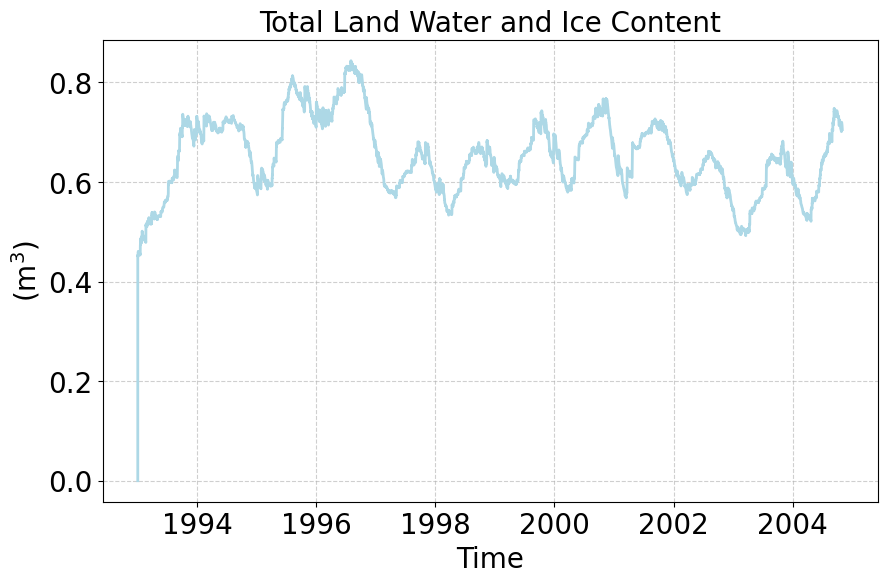

In [ ]:
# Plot total land water and ice content for AU-Preston (current)
plt.figure(figsize=(10, 6))
au_preston_current_wbal_weq_land.plot(color="lightblue", linewidth=2)
plt.title("Total Land Water and Ice Content", fontsize=20)
plt.xlabel("Time", fontsize=20)
plt.ylabel("(m$^{3}$)", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

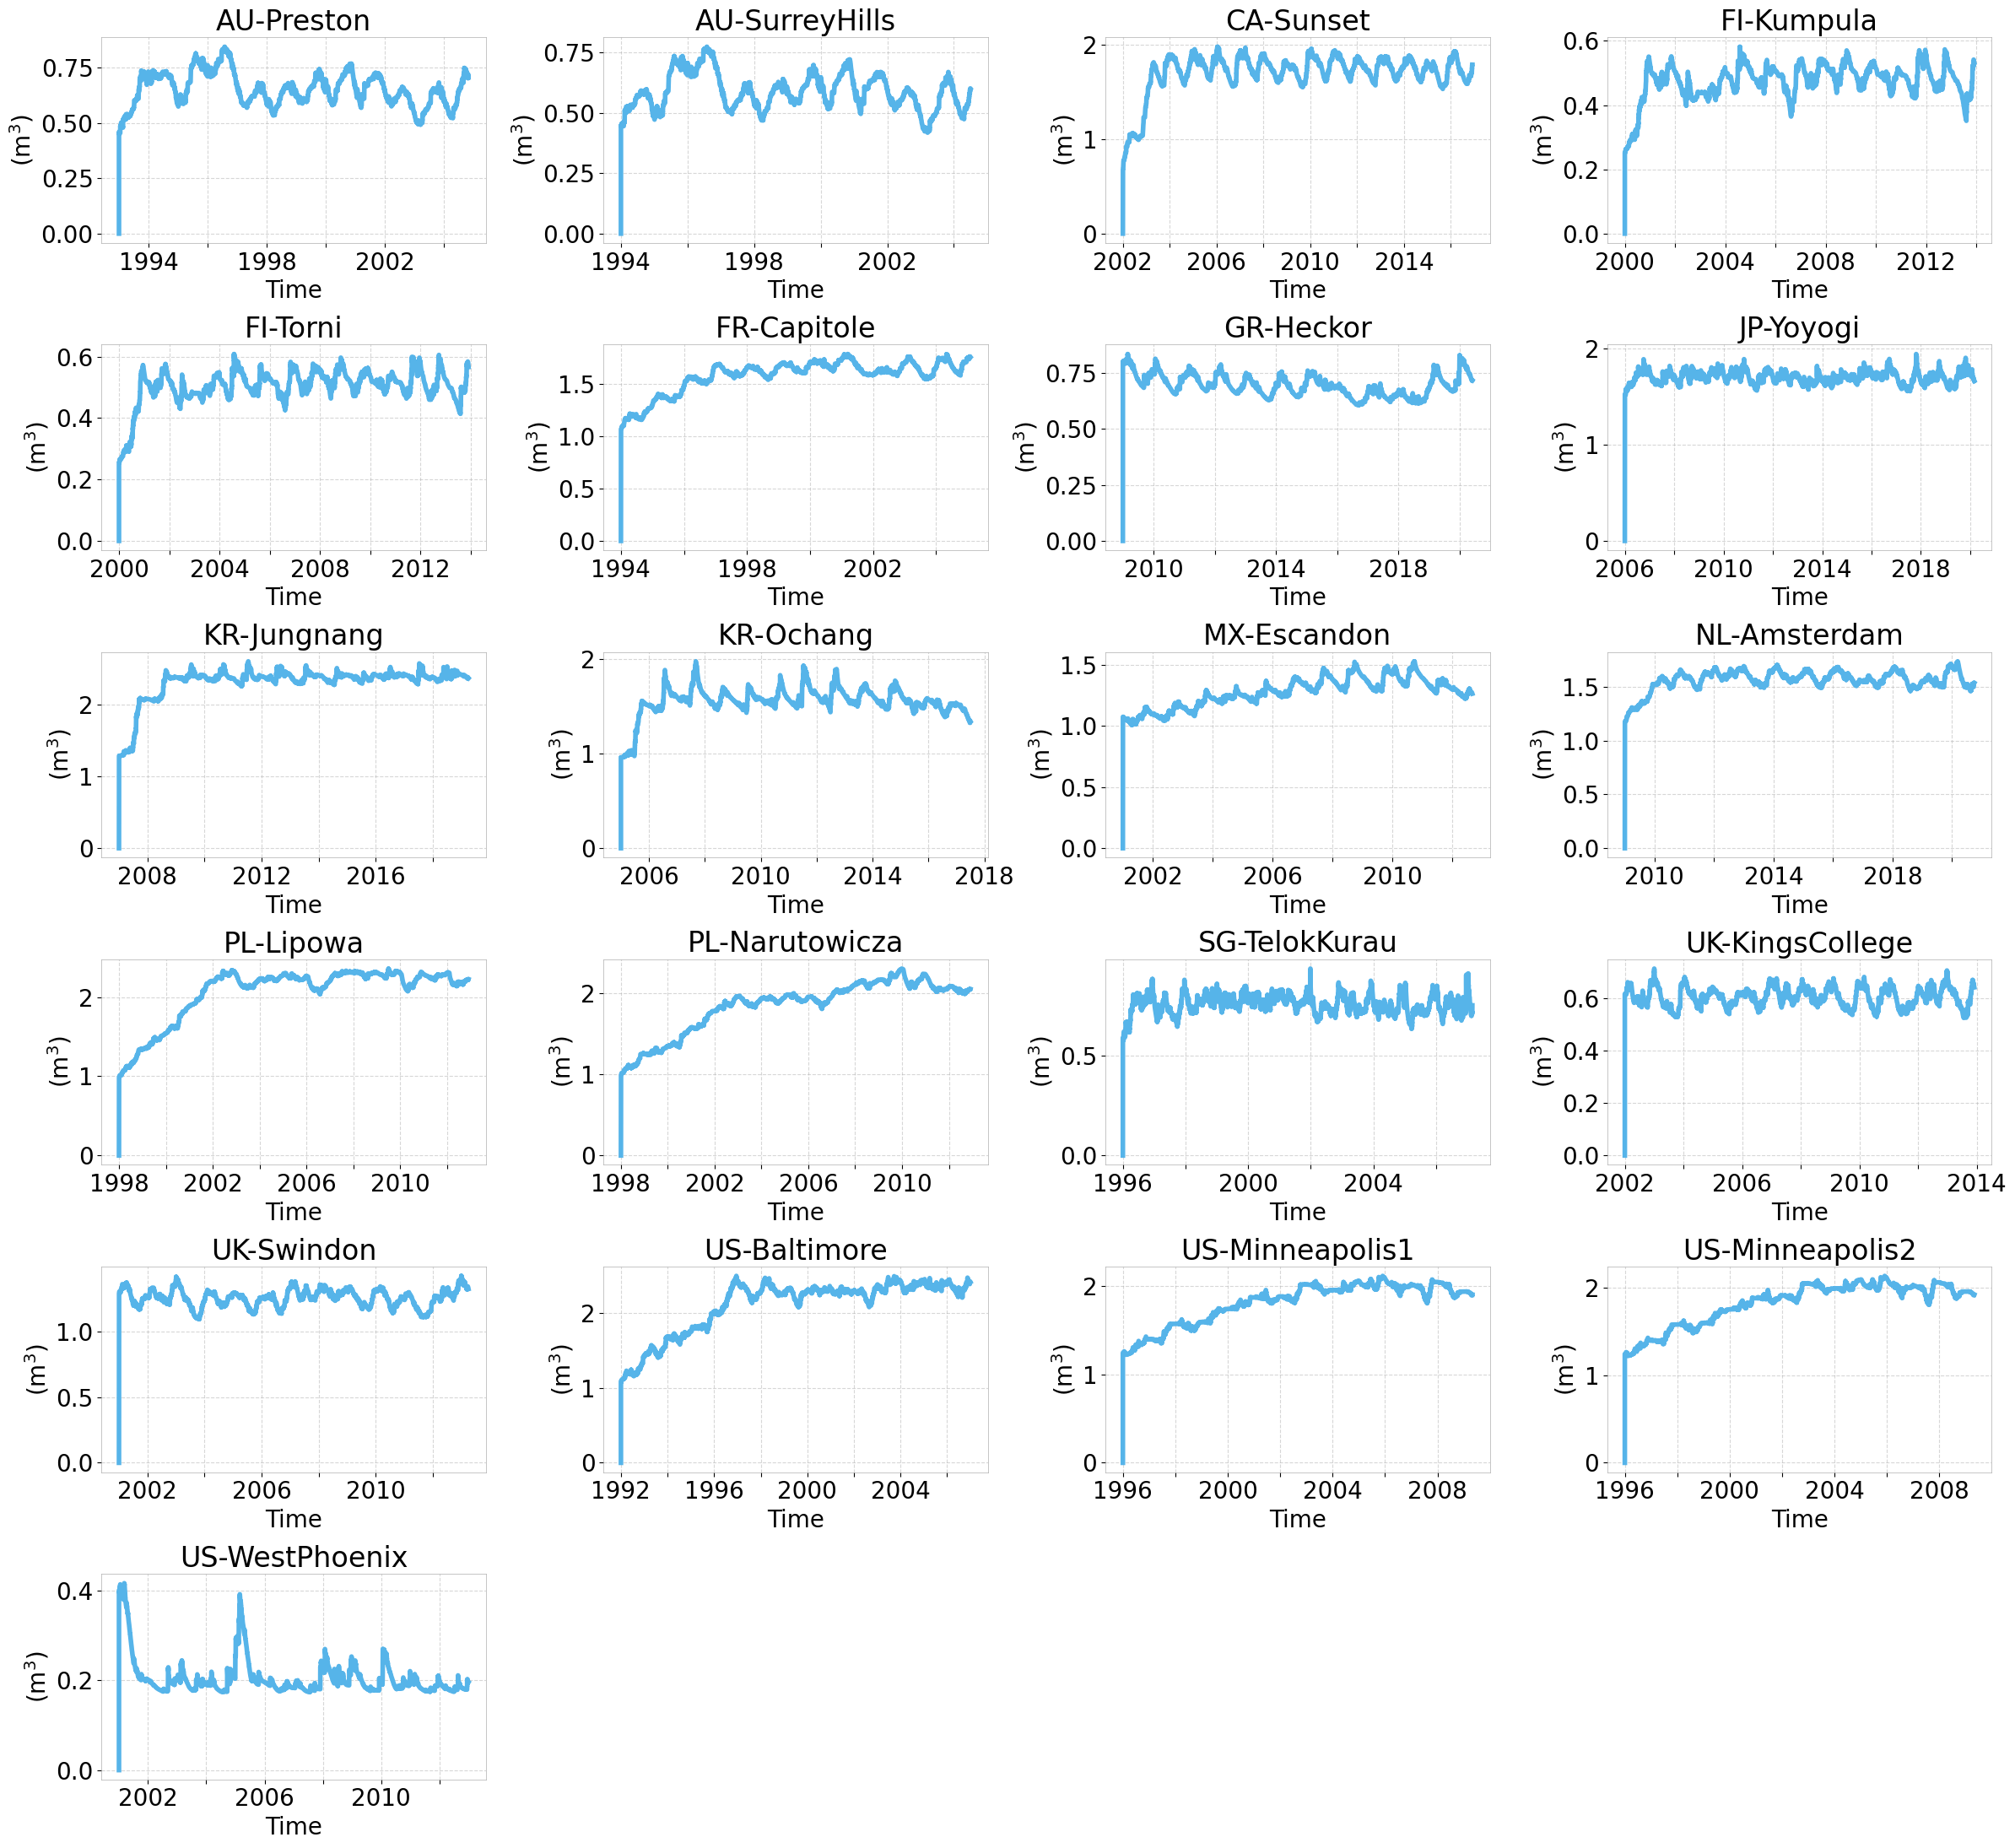

In [ ]:
# Plot total land water and ice content for all sites (current)

sites_info = [
    ("au-preston", "19930101T000000Z", "AU-Preston"),
    ("au-surreyhills", "19940101T000000Z", "AU-SurreyHills"),
    ("ca-sunset", "20020101T000000Z", "CA-Sunset"),
    ("fi-kumpula", "20000101T000000Z", "FI-Kumpula"),
    ("fi-torni", "20000101T000000Z", "FI-Torni"),
    ("fr-capitole", "19940101T000000Z", "FR-Capitole"),
    ("gr-heckor", "20090101T000000Z", "GR-Heckor"),
    ("jp-yoyogi", "20060101T000000Z", "JP-Yoyogi"),
    ("kr-jungnang", "20070101T000000Z", "KR-Jungnang"),
    ("kr-ochang", "20050101T000000Z", "KR-Ochang"),
    ("mx-escandon", "20010101T000000Z", "MX-Escandon"),
    ("nl-amsterdam", "20090101T000000Z", "NL-Amsterdam"),
    ("pl-lipowa", "19980101T000000Z", "PL-Lipowa"),
    ("pl-narutowicza", "19980101T000000Z", "PL-Narutowicza"),
    ("sg-telokkurau06", "19960101T000000Z", "SG-TelokKurau"),
    ("uk-kingscollege", "20020101T000000Z", "UK-KingsCollege"),
    ("uk-swindon", "20010101T000000Z", "UK-Swindon"),
    ("us-baltimore", "19920101T000000Z", "US-Baltimore"),
    ("us-minneapolis1", "19960101T000000Z", "US-Minneapolis1"),
    ("us-minneapolis2", "19960101T000000Z", "US-Minneapolis2"),
    ("us-westphoenix", "20010101T000000Z", "US-WestPhoenix")
]
                       
# Create a 5x5 grid of subplots
fig, axes = plt.subplots(6, 4, figsize=(24,22), sharex=False, sharey=False)

axes_flat = axes.flatten()

# Create individual plot for each site
for i, (site, timestamp, title) in enumerate(sites_info):
    ax = axes_flat[i] 

    file_path = f"/cluster/work/climate/kepp/icon-mpim/experiments/land_jsbach_sitelevel_current_{site}/land_jsbach_sitelevel_current_{site}_lnd_wbal_{site}_ml_{timestamp}.nc"

    try:
        ds = xr.open_dataset(file_path)

        ds.hydro_weq_land_box.plot(ax=ax, color="#56B4E9", linewidth=4)

        ax.set_title(title, fontsize=24)
        ax.set_xlabel("Time", fontsize=20)
        ax.set_ylabel("(m$^{3}$)", fontsize=20)
        ax.tick_params(axis="both", labelsize=20)
        ax.grid(True, linestyle="--", alpha=0.5)

        # Make frames thinner and gray
        for spine in ax.spines.values():
            spine.set_linewidth(0.4)
            spine.set_color('#999999')

        for label in ax.xaxis.get_ticklabels()[::2]:  # Skip every second label
            label.set_visible(False)

        ds.close()

    except FileNotFoundError:
        ax.text(
            0.5,
            0.5,
            "File Not Found",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.set_title(f"{site} (Missing)", fontsize=24)
    except Exception as e:
        ax.text(
            0.5,
            0.5,
            "Error Loading",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.set_title(f"{site} (Error)", fontsize=24)

# Hide remaining unused subplots
for j in range(len(sites_info), len(axes_flat)):
    axes_flat[j].axis("off")

plt.tight_layout()  # Adjust spacing so text does not overlap

plt.savefig("spinup_assessment.pdf", bbox_inches="tight")

plt.show()

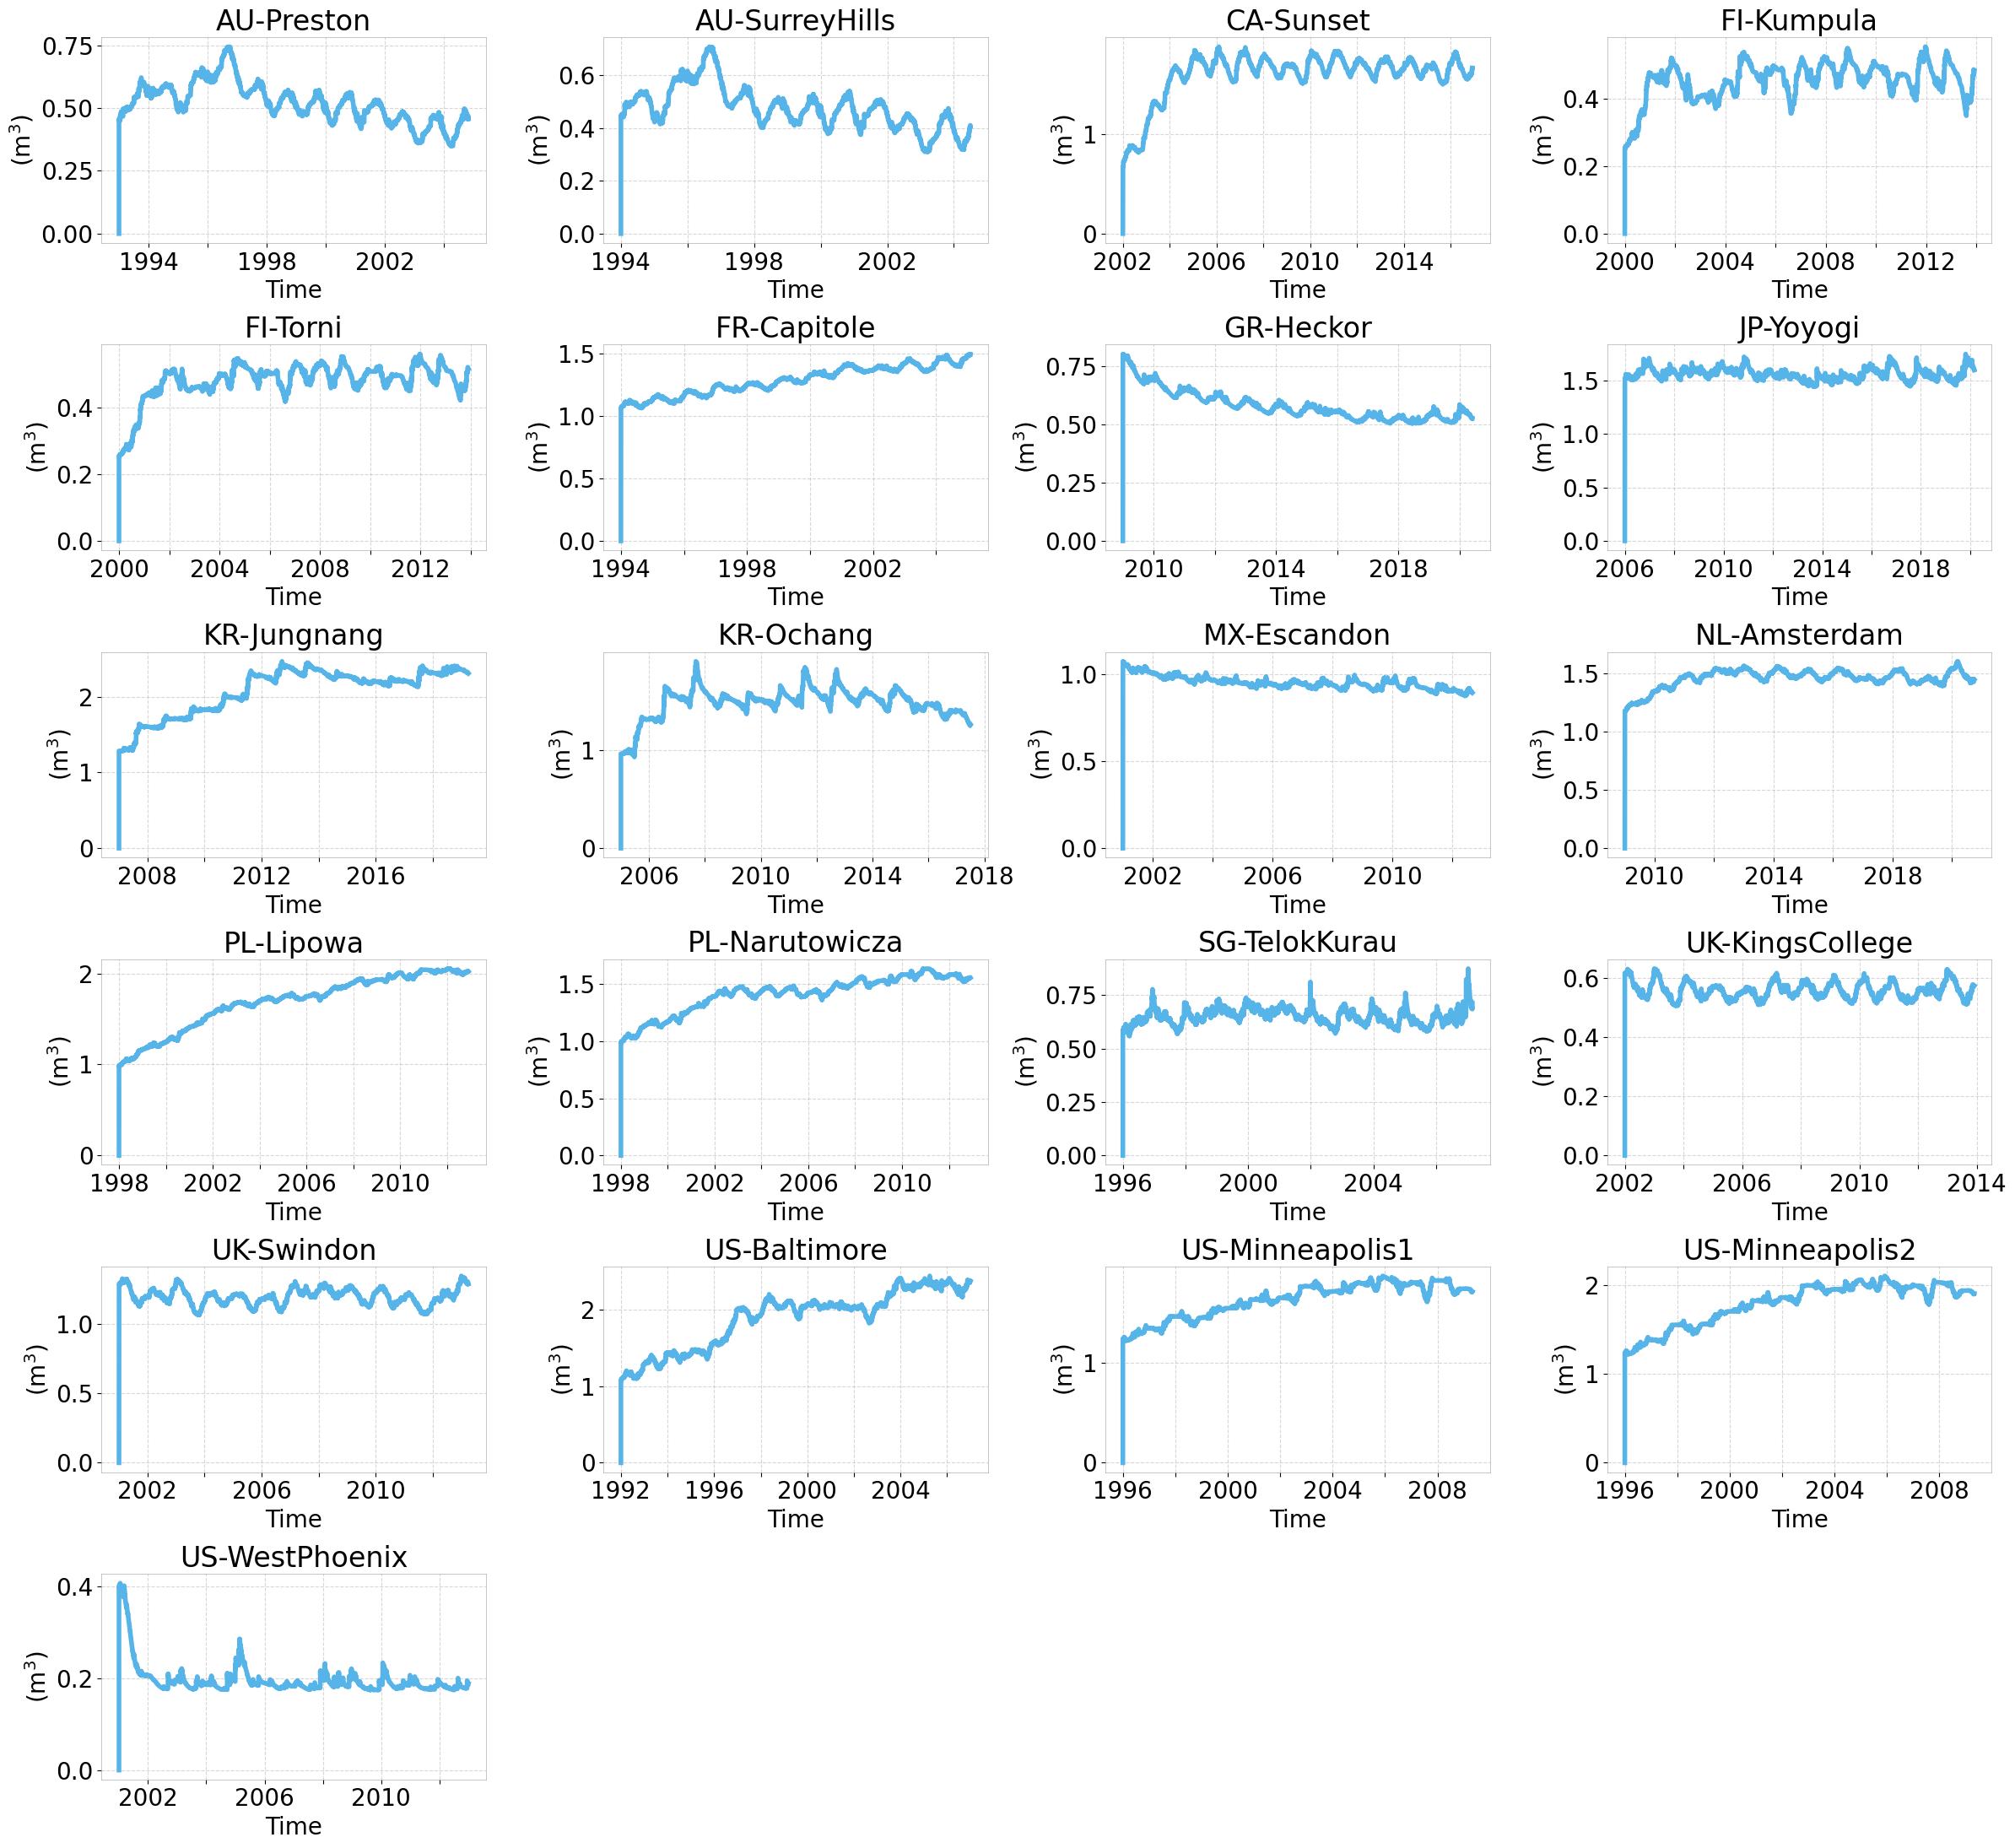

In [ ]:
# Plot total land water and ice content for all sites (hcc_hyd)

sites_info = [
    ("au-preston", "19930101T000000Z", "AU-Preston"),
    ("au-surreyhills", "19940101T000000Z", "AU-SurreyHills"),
    ("ca-sunset", "20020101T000000Z", "CA-Sunset"),
    ("fi-kumpula", "20000101T000000Z", "FI-Kumpula"),
    ("fi-torni", "20000101T000000Z", "FI-Torni"),
    ("fr-capitole", "19940101T000000Z", "FR-Capitole"),
    ("gr-heckor", "20090101T000000Z", "GR-Heckor"),
    ("jp-yoyogi", "20060101T000000Z", "JP-Yoyogi"),
    ("kr-jungnang", "20070101T000000Z", "KR-Jungnang"),
    ("kr-ochang", "20050101T000000Z", "KR-Ochang"),
    ("mx-escandon", "20010101T000000Z", "MX-Escandon"),
    ("nl-amsterdam", "20090101T000000Z", "NL-Amsterdam"),
    ("pl-lipowa", "19980101T000000Z", "PL-Lipowa"),
    ("pl-narutowicza", "19980101T000000Z", "PL-Narutowicza"),
    ("sg-telokkurau06", "19960101T000000Z", "SG-TelokKurau"),
    ("uk-kingscollege", "20020101T000000Z", "UK-KingsCollege"),
    ("uk-swindon", "20010101T000000Z", "UK-Swindon"),
    ("us-baltimore", "19920101T000000Z", "US-Baltimore"),
    ("us-minneapolis1", "19960101T000000Z", "US-Minneapolis1"),
    ("us-minneapolis2", "19960101T000000Z", "US-Minneapolis2"),
    ("us-westphoenix", "20010101T000000Z", "US-WestPhoenix")
]
                       
# Create a 5x5 grid of subplots
fig, axes = plt.subplots(6, 4, figsize=(24,22), sharex=False, sharey=False)

axes_flat = axes.flatten()

# Create individual plot for each site
for i, (site, timestamp, title) in enumerate(sites_info):
    ax = axes_flat[i]

    file_path = f"/cluster/work/climate/kepp/urban_implementation/icon-mpim/experiments/land_jsbach_sitelevel_hcc_hyd_{site}/land_jsbach_sitelevel_hcc_hyd_{site}_lnd_wbal_{site}_ml_{timestamp}.nc"

    try:
        ds = xr.open_dataset(file_path)

        ds.hydro_weq_land_box.plot(ax=ax, color="#56B4E9", linewidth=4)

        ax.set_title(title, fontsize=24)
        ax.set_xlabel("Time", fontsize=20)
        ax.set_ylabel("(m$^{3}$)", fontsize=20)
        ax.tick_params(axis="both", labelsize=20)
        ax.grid(True, linestyle="--", alpha=0.5)

        # Make frames thinner and gray
        for spine in ax.spines.values():
            spine.set_linewidth(0.4)
            spine.set_color('#999999')

        for label in ax.xaxis.get_ticklabels()[::2]:  # Skip every second label
            label.set_visible(False)

        ds.close()

    except FileNotFoundError:
        ax.text(
            0.5,
            0.5,
            "File Not Found",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.set_title(f"{site} (Missing)", fontsize=24)
    except Exception as e:
        ax.text(
            0.5,
            0.5,
            "Error Loading",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.set_title(f"{site} (Error)", fontsize=24)

# Hide remaining unused subplots
for j in range(len(sites_info), len(axes_flat)):
    axes_flat[j].axis("off")

plt.tight_layout()  # Adjust spacing nicely so text does not overlap

plt.savefig("spinup_assessment_hcc_hyd.pdf", bbox_inches="tight")

plt.show()